In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

<H1 style=color:red>Loading The Data</H1>

In [16]:
# Load Data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df=pd.read_csv(url)
# df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df['log_passengers'] = np.log(df['Passengers'])

<h1>Feature Engineering: Add lag and rolling mean features</h1>

In [19]:
df['lag_1'] = df['log_passengers'].shift(1)
df['lag_12'] = df['log_passengers'].shift(12)
df['rolling_mean_3'] = df['log_passengers'].rolling(window=3).mean().shift(1)
df = df.dropna()

<h1>Scaling Features</h1>

In [18]:
scaler = MinMaxScaler()
features = ['log_passengers', 'lag_1', 'lag_12', 'rolling_mean_3']
scaled = scaler.fit_transform(df[features])


<h1>Sequence preparation</h1>

In [20]:
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, 0])  # log_passengers is the target
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled, window_size)

<h1>Train/Test split</h1>

In [21]:
split = len(X) - 24
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

<h1>Model</h1>

In [22]:
model = Sequential([
    LSTM(60, activation='relu', input_shape=(window_size, X.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(30, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.1371 - val_loss: 0.0554
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0208 - val_loss: 0.0267
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0149 - val_loss: 0.0269
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0181 - val_loss: 0.0160
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0123 - val_loss: 0.0109
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0097 - val_loss: 0.0155
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0110 - val_loss: 0.0105
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0135 - val_loss: 0.0114
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0171 - val_loss: 0.0104
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0089 - val_loss: 0.0107
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0086 - val_loss: 0.0118
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0

<h1>Predict and Inverse Tranform Predictions</h1>

In [23]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

def inverse_transform(pred, orig, scaler, features):
    temp = np.zeros((len(pred), len(features)))
    temp[:,0] = pred.flatten()
    inv = scaler.inverse_transform(temp)[:,0]
    return np.exp(inv)

y_train_inv = inverse_transform(y_train, X_train, scaler, features)
y_train_pred_inv = inverse_transform(y_train_pred, X_train, scaler, features)
y_test_inv = inverse_transform(y_test, X_test, scaler, features)
y_test_pred_inv = inverse_transform(y_test_pred, X_test, scaler, features)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


<h1>Metrics</h1>

In [24]:
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train_inv, y_train_pred_inv):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test_inv, y_test_pred_inv):.2f}")

Train RMSE: 25.43
Test RMSE: 32.27
Train MAE: 19.61
Test MAE: 26.93


# Plot

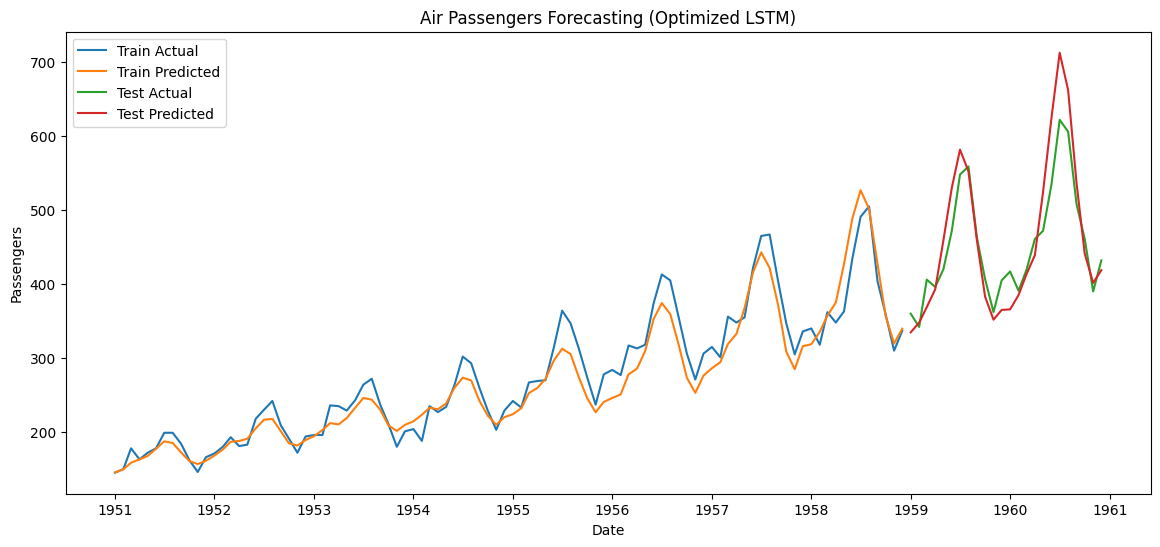

In [13]:
plt.figure(figsize=(14,6))
plt.plot(df.index[window_size:split+window_size], y_train_inv, label='Train Actual')
plt.plot(df.index[window_size:split+window_size], y_train_pred_inv, label='Train Predicted')
plt.plot(df.index[split+window_size:], y_test_inv, label='Test Actual')
plt.plot(df.index[split+window_size:], y_test_pred_inv, label='Test Predicted')
plt.title('Air Passengers Forecasting (Optimized LSTM)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()